# Descriptive Statistics of the US Poverty Rate from 2018 to 2022
An exploratory data analysis of the National Database of Childcare Prices 2022 dataset to understand some key socio-economic variables accross the States in the United States of America and their influence on poverty rate levels in those States.

## 1.0) Overview

**Key Objectives of the Analysis**
* Analyse the US unemployment rate of males and females across 5 years (2018 to 2022).
* Analyse the unemployment rate per state and their relationship to the poverty rate levels in 2022.
* Analyse the median household income per State against the poverty rate per State in 2022.
* Analyse the effects of houseolds with only the father working compared to the both parents working on the poverty rate in the States in 2022.
* Analyse the median weekly family childcare and centre-based cares price against the poverty rate per US State in 2022.

__Key Variables__  
1) Unemploymet rate
2) Median household income per State
3) Number of houseolds with only the father working
4) Number of houseolds with both parents working
5) Median weekly centre-based care price
6) Median weekly Family childcare price
7) Poverty rate

## 2.0) Data Import and Preparation

### 2.1) Importing the Data and Python Packages Necessary
**Data Source**  
The National Database of Childcare Prices (NDCP) under the United States Department of Labour. https://dataportal.dol.gov/datasets/10278

In [1]:
#import necessary libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings

In [2]:
warnings.filterwarnings("ignore") #to avoid clogging the notebook with warnings, they will be filtered

In [3]:
#import the raw data
raw_df = pd.read_csv("./dataset/NDCP_2022_dataset.csv")
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48308 entries, 0 to 48307
Columns: 370 entries, state_name to ifemp_p_state
dtypes: float64(200), int64(167), str(3)
memory usage: 136.4 MB


In [4]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
county_fips_code,48308.0,31394.875362,16291.031838,1001.0,19032.5,30025.0,46107.0,72153.0
studyyear,48308.0,2014.999959,4.320660,2008.0,2011.0,2015.0,2019.0,2022.0
emr_16,48308.0,54.860845,8.743072,11.0,49.5,55.6,61.2,98.3
femr_16,48308.0,50.968001,7.994420,13.6,46.0,51.4,56.5,100.0
memr_16,48308.0,58.979668,10.430401,8.0,52.9,60.2,66.4,100.0
...,...,...,...,...,...,...,...,...
imemp_n_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
ifemp_n_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
iemp_p_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
imemp_p_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


In [5]:
raw_df.head()

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,emr_16,femr_16,memr_16,emr_20to64,femr_20to64,...,ifemp_service_state,iemp_sales_state,imemp_sales_state,ifemp_sales_state,iemp_n_state,imemp_n_state,ifemp_n_state,iemp_p_state,imemp_p_state,ifemp_p_state
0,Alabama,AL,Autauga County,1001,2008,61.5,56.1,67.3,71.4,66.3,...,1,1,1,1,1,1,1,1,1,1
1,Alabama,AL,Autauga County,1001,2009,60.6,54.8,67.0,72.5,66.9,...,1,1,1,1,1,1,1,1,1,1
2,Alabama,AL,Autauga County,1001,2010,60.4,54.9,66.4,72.3,67.4,...,1,1,1,1,1,1,1,1,1,1
3,Alabama,AL,Autauga County,1001,2011,58.7,52.4,65.6,71.0,64.9,...,1,1,1,1,1,1,1,1,1,1
4,Alabama,AL,Autauga County,1001,2012,57.7,52.2,63.8,70.7,65.1,...,1,1,1,1,1,1,1,1,1,1


### 2.2) Processing and Preparing the Dataset for Analysis

The dataset contains 48,308 observations and 370 attributes. Half of the attributes are metadata attributes that specify whether data was systematically imputed for a particular missing attribute of an observation e.g. `iemr_16_state` is a binary data that specifies whether the 'employment rate of females in the county' for an observation was systematically imputed. These metadata columns and other attributes with low level of relevance to the key objectives of analysis will be removed.

Since the analysis focuses on the period of 2018 to 2022, only the observations captured at that period will be retained.

The relevant attributes are:  

| Field Name | Field Description | Intended Data Type |
|------------|------------------|--------------------|
| state_name | Name of state for which the data are being entered. | categorical
| state_abbreviation | Two-letter state abbreviation | categorical
| county_name | Name of the county for which data are being entered. | categorical
| county_fips_code | Five-digit number that uniquely identifies the county in a state. | categorical
| studyyear | Year in which data were collected for the market rate survey. | categorical
| unr_16 | Unemployment rate of the population aged 16 years old or older | numeric |
| funr_16 | Unemployment rate of the female population aged 16 years old or older | numeric |
| munr_16 | Unemployment rate of the male population aged 16 years old or older | numeric |
| mhi_2022 | Median household income expressed in 2022 dollars | numeric |
| totalpop | Count of the total population | numeric |
| h_under6_fwork | Number of households with children under 6 years old with only the father working | numeric |
| h_under6_mwork | Number of households with children under 6 years old with only the mother working | numeric |
| h_under6_singlem | Number of households with children under 6 years old with a single mother | numeric |
| h_6to17_fwork | Number of households with children between 6 and 17 years old with only the father working | numeric |
| h_6to17_mwork | Number of households with children between 6 and 17 years old with only the mother working | numeric |
| h_6to17_singlem | Number of households with children between 6 and 17 years old with a single mother | numeric |
| h_under6_bothwork | Number of households with children under 6 years old with two working parents | numeric |
| h_6to17_bothwork | Number of households with children between 6 and 17 years old with two working parents | numeric |
| mcbto5 | Weekly, full-time median price charged for Center-Based Care for those aged 0 to 5 months | numeric |
| mc6to11 | Weekly, full-time median price charged for Center-Based Care for those aged 6 to 11 months | numeric |
| mc12to17 | Weekly, full-time median price charged for Center-Based Care for those aged 12 to 17 months | numeric |
| mc18to23 | Weekly, full-time median price charged for Center-Based Care for those aged 18 to 23 months | numeric |
| mc24to29 | Weekly, full-time median price charged for Center-Based Care for those aged 24 to 29 months | numeric |
| mc30to35 | Weekly, full-time median price charged for Center-Based Care for those aged 30 to 35 months | numeric |
| mc36to41 | Weekly, full-time median price charged for Center-Based Care for those aged 36 to 41 months | numeric |
| mc42to47 | Weekly, full-time median price charged for Center-Based Care for those aged 42 to 47 months | numeric |
| mc48to53 | Weekly, full-time median price charged for Center-Based Care for those aged 48 to 53 months | numeric |
| mc54tosa | Weekly, full-time median price charged for Center-Based Care for those aged 54 months to school age | numeric |
| mcsa | Weekly, full-time median price charged for Center-Based Care for those who are school age | numeric |
| mfccbto5 | Weekly, full-time median price charged for Family Childcare for those aged 0 to 5 months | numeric |
| mfcc6to11 | Weekly, full-time median price charged for Family Childcare for those aged 6 to 11 months | numeric |
| mfcc12to17 | Weekly, full-time median price charged for Family Childcare for those aged 12 to 17 months | numeric |
| mfcc18to23 | Weekly, full-time median price charged for Family Childcare for those aged 18 to 23 months | numeric |
| mfcc24to29 | Weekly, full-time median price charged for Family Childcare for those aged 24 to 29 months | numeric |
| mfcc30to35 | Weekly, full-time median price charged for Family Childcare for those aged 30 to 35 months | numeric |
| mfcc36to41 | Weekly, full-time median price charged for Family Childcare for those aged 36 to 41 months | numeric |
| mfcc42to47 | Weekly, full-time median price charged for Family Childcare for those aged 42 to 47 months | numeric |
| mfcc48to53 | Weekly, full-time median price charged for Family Childcare for those aged 48 to 53 months | numeric |
| mfcc54tosa | Weekly, full-time median price charged for Family Childcare for those aged 54 months to school age | numeric |
| mfccsa | Weekly, full-time median price charged for Family Childcare for those who are school age | numeric |
| pr_p | Poverty rate for individuals | numeric |

#### i) Filtering for the Relevant Columns and rows

In [6]:
#filter for the relevant variables
filtered_df = raw_df[["state_name", "state_abbreviation","county_name", "county_fips_code", "studyyear", "unr_16", "funr_16", "munr_16", "mhi_2022", "totalpop", "h_under6_fwork", "h_under6_mwork", "h_under6_singlem", "h_6to17_fwork", "h_6to17_mwork", "h_6to17_singlem", "h_under6_bothwork", "h_6to17_bothwork", "mcbto5", "mc6to11", "mc12to17", "mc18to23", "mc24to29", "mc30to35", "mc36to41", "mc42to47", "mc48to53", "mc54tosa", "mcsa", "mfccbto5", "mfcc6to11", "mfcc12to17", "mfcc18to23", "mfcc24to29", "mfcc30to35", "mfcc36to41", "mfcc42to47", "mfcc48to53", "mfcc54tosa", "mfccsa", "pr_p"]]
filtered_df = filtered_df[filtered_df["studyyear"] >= 2018] #filter only data from 2018 to 2022
filtered_df = filtered_df.reset_index(drop=True) #reset the indexes so that the dataset is arranged well
filtered_df.head()

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc12to17,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p
0,Alabama,AL,Autauga County,1001,2018,4.2,3.4,4.9,69367,55200,...,112.33,112.33,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4
1,Alabama,AL,Autauga County,1001,2019,3.7,3.2,4.1,68128,55380,...,117.55,117.55,116.05,115.62,115.62,115.62,115.62,115.62,110.20,15.2
2,Alabama,AL,Autauga County,1001,2020,2.9,2.4,3.3,66679,55639,...,122.78,122.78,120.53,120.31,120.31,120.31,120.31,120.31,112.60,15.2
3,Alabama,AL,Autauga County,1001,2021,2.8,2.3,3.3,68299,58239,...,128.00,128.00,125.00,125.00,125.00,125.00,125.00,125.00,115.00,13.6
4,Alabama,AL,Autauga County,1001,2022,2.8,2.6,2.9,68315,58761,...,133.23,133.23,129.48,129.69,129.69,129.69,129.69,129.69,117.40,11.4


In [7]:
filtered_df.shape #show the shape of the dataset

(16103, 41)

By focusing only on variables and rows that are relevant to this analysis project, the total number of relvant rows is 16,103 and the number of variables is 40.

#### ii) Treating Blanks
Checking the rows for blanks

In [8]:
print("List of columns and their number of blanks rows:")
filtered_df.isna().sum()

List of columns and their number of blanks rows:


state_name               0
state_abbreviation       0
county_name              0
county_fips_code         0
studyyear                0
unr_16                   0
funr_16                  0
munr_16                  0
mhi_2022                 0
totalpop                 0
h_under6_fwork           0
h_under6_mwork           0
h_under6_singlem         0
h_6to17_fwork            0
h_6to17_mwork            0
h_6to17_singlem          0
h_under6_bothwork        0
h_6to17_bothwork         0
mcbto5                2639
mc6to11               2639
mc12to17              2627
mc18to23              2627
mc24to29              2618
mc30to35              2618
mc36to41              2602
mc42to47              2602
mc48to53              2602
mc54tosa              2602
mcsa                  2673
mfccbto5              3019
mfcc6to11             3019
mfcc12to17            3018
mfcc18to23            3018
mfcc24to29            3026
mfcc30to35            3026
mfcc36to41            3014
mfcc42to47            3014
m

The blank rows of each attribute for each State will be replaced by the mean of that attribute for that State alone instead of the general attribute's column to avoid filling the blanks of some State with values that may be larger than average due to some states with high variable values.

In [9]:
states_abvs = filtered_df["state_abbreviation"].value_counts().index #getting the list of states' abbreviations

In [10]:
#creating a reusable function for filling all blank rows in all the columns of a dataframe with their respective means
def fill_blanks_with_mean(series):
    if(series.dtype != "string"): #this is to skip string-type columns to avoid having error when the mean is being calculated
        n_series = series.fillna(series.mean())
        return n_series
    else:
        return series

In [11]:
#creating a reusable function for filling all blank rows in all the columns of a dataframe with their respective medians
def fill_blanks_with_median(series):
    if(series.dtype != "string"): #this is to skip string-type columns to avoid having error when the median is being calculated
        n_series = series.fillna(series.median())
        return n_series
    else:
        return series

In [12]:
#replacing blanks in each subset of the data for each State with their respective averages
for state_ID in states_abvs:
    filtered_df[filtered_df["state_abbreviation"] == state_ID] = filtered_df[filtered_df["state_abbreviation"] == state_ID].apply(fill_blanks_with_mean)

In [13]:
def show_cols_with_blanks(df):
    count = 0
    for col in filtered_df.columns:
        blank_count = df[col].isna().sum()
        if(blank_count > 0):
            count += 1
            print(f"'{col}' contains {blank_count} blanks")

    if(count == 0):
        print("There are no more blank rows")

In [14]:
show_cols_with_blanks(filtered_df) #confirming if any column still contain blanks, if there is any, show them

'mcbto5' contains 625 blanks
'mc6to11' contains 625 blanks
'mc12to17' contains 625 blanks
'mc18to23' contains 625 blanks
'mc24to29' contains 625 blanks
'mc30to35' contains 625 blanks
'mc36to41' contains 625 blanks
'mc42to47' contains 625 blanks
'mc48to53' contains 625 blanks
'mc54tosa' contains 625 blanks
'mcsa' contains 630 blanks
'mfccbto5' contains 625 blanks
'mfcc6to11' contains 625 blanks
'mfcc12to17' contains 625 blanks
'mfcc18to23' contains 625 blanks
'mfcc24to29' contains 625 blanks
'mfcc30to35' contains 625 blanks
'mfcc36to41' contains 625 blanks
'mfcc42to47' contains 625 blanks
'mfcc48to53' contains 625 blanks
'mfcc54tosa' contains 625 blanks
'mfccsa' contains 630 blanks


Checking the names of the States that still have blank rows

In [15]:
print("The names of states still having blanks:")
filtered_df[filtered_df["mc18to23"].isna()]["state_name"].value_counts() #check the names of the States with blanks

The names of states still having blanks:


state_name
Indiana       460
New Mexico    165
Name: count, dtype: int64

The States of Indiana and New Mexico appears to not have any values inputed for all categories of __"child care prices"__, these will be filled with the national **median** from all the States. The median is used instead of the mean to avoid influencing the values with high variables/outliers from some States.

In [16]:
filtered_df = filtered_df.apply(fill_blanks_with_median) #fill all remaining blank rows in each attribute with the national median of each attribute

In [17]:
show_cols_with_blanks(filtered_df) #check if there is still any blank rows

There are no more blank rows


In [18]:
#checking the observations from the State of Indiana again
filtered_df[filtered_df["state_abbreviation"] == "IN"].head()

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc12to17,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p
3488,Indiana,IN,Adams County,18001,2018,3.6,3.7,3.6,61021,35195,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,16.8
3489,Indiana,IN,Adams County,18001,2019,3.6,3.7,3.5,60905,35376,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,16.8
3490,Indiana,IN,Adams County,18001,2020,3.0,3.1,3.0,60619,35544,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,16.5
3491,Indiana,IN,Adams County,18001,2021,3.0,3.3,2.8,61080,35685,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,15.3
3492,Indiana,IN,Adams County,18001,2022,3.2,3.0,3.4,61731,35827,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,11.5


#### iii) Feature Engineering
The dataset contains many attributes that were recorded per cluster, for example; the attributes representing __Number of houseolds where both parents are working__ were recorded in child age-group clusters. For the goal of this analysis, some of the cluster-based attributes are not needed as they will be analysed as a whole, hence, the dataset will be normalised into the first normal form by combining some of the related attributes into a singular attribute or dropping redundant attributes like in the case of __'unemployment rate'__ where the value can be derived from the gender-based unemployment rate attributes.

The following are the steps that will be taken to get the final dataset that will meet the requirement of this analysis:

* Dropping the general unemployment rate attribute (`unr_16`) from the table since the value can be derived from the gender-based unemployment rate attributes.

In [19]:
filtered_df = filtered_df.drop("unr_16", axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,funr_16,munr_16,mhi_2022,totalpop,h_under6_fwork,...,mfcc12to17,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,1332,...,112.33,112.33,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4


* Merging the various attributes that represent the number of houseolds with only one parent working into a single attribute.

In [20]:
filtered_df["1_bread_winner_hh"] = (filtered_df["h_under6_fwork"] + filtered_df["h_under6_mwork"] + filtered_df["h_under6_singlem"] + filtered_df["h_6to17_fwork"] + filtered_df["h_6to17_mwork"] + filtered_df["h_6to17_singlem"]).astype("int64")
#Dropping the extra columns that are no more needed
filtered_df = filtered_df.drop(["h_under6_fwork", "h_under6_mwork", "h_under6_singlem", "h_6to17_fwork", "h_6to17_mwork", "h_6to17_singlem"], axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,funr_16,munr_16,mhi_2022,totalpop,h_under6_bothwork,...,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p,1_bread_winner_hh
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,1261,...,112.33,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4,6127


* Merging the two attributes that represent number of houseold that has both parents working

In [21]:
filtered_df["2_bread_winner_hh"] = (filtered_df["h_under6_bothwork"] + filtered_df["h_6to17_bothwork"]).astype("int64")
filtered_df = filtered_df.drop(["h_under6_bothwork", "h_6to17_bothwork"], axis=1) #dropping the extra columns that are no more needed
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,funr_16,munr_16,mhi_2022,totalpop,mcbto5,...,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p,1_bread_winner_hh,2_bread_winner_hh
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,122.59,...,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4,6127,5523


* Merging the values of the median centre-base care prices accross the children age groups into a single attribute using the average of them all

In [22]:
# find the mean accross all the age-groups of the median centre-based care prices and assign it into a new single attribute
filtered_df["avg_centrebased_care_price"] = filtered_df[["mcbto5", "mc6to11", "mc12to17", "mc18to23", "mc24to29", "mc30to35", "mc36to41", "mc42to47", "mc48to53", "mc54tosa", "mcsa"]].mean(axis=1)
#dropping the extra columns that are no more needed
filtered_df = filtered_df.drop(["mcbto5", "mc6to11", "mc12to17", "mc18to23", "mc24to29", "mc30to35", "mc36to41", "mc42to47", "mc48to53", "mc54tosa", "mcsa"], axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,funr_16,munr_16,mhi_2022,totalpop,mfccbto5,...,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p,1_bread_winner_hh,2_bread_winner_hh,avg_centrebased_care_price
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,112.83,...,110.93,110.93,110.93,110.93,110.93,107.79,15.4,6127,5523,112.346364


* Using the mean, the median family childcare prices accross the age-groups will be merged into one

In [23]:
filtered_df["avg_family_childcare_price"] = filtered_df[["mfccbto5", "mfcc6to11", "mfcc12to17", "mfcc18to23", "mfcc24to29", "mfcc30to35", "mfcc36to41", "mfcc42to47", "mfcc48to53", "mfcc54tosa", "mfccsa"]].mean(axis=1)
 #dropping the extra columns that are no more needed
filtered_df = filtered_df.drop(["mfccbto5", "mfcc6to11", "mfcc12to17", "mfcc18to23", "mfcc24to29", "mfcc30to35", "mfcc36to41", "mfcc42to47", "mfcc48to53", "mfcc54tosa", "mfccsa"], axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,funr_16,munr_16,mhi_2022,totalpop,pr_p,1_bread_winner_hh,2_bread_winner_hh,avg_centrebased_care_price,avg_family_childcare_price
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,15.4,6127,5523,112.346364,111.303636


* The attributes in the table below will be renamed for clarity.  

|Current Name   |New Name               |
|---------------|-----------------------|
|funr_16        |female_unemployed_rate |
|munr_16        |male_unemployed_rate   |
|mhi_2022       |2022_med_household_inc |
|pr_p           |poverty_rate           |

In [24]:
#renaming some of the attributes for clarity
filtered_df = filtered_df.rename({
    "totalpop": "population",
    "funr_16": "female_unemployed_rate",
    "munr_16": "male_unemployed_rate",
    "mhi_2022": "2022_med_household_inc",
    "pr_p": "poverty_rate",
}, axis=1)

filtered_df.head(3)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_bread_winner_hh,2_bread_winner_hh,avg_centrebased_care_price,avg_family_childcare_price
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,15.4,6127,5523,112.346364,111.303636
1,Alabama,AL,Autauga County,1001,2019,3.2,4.1,68128,55380,15.2,5686,5630,117.388182,116.050000
2,Alabama,AL,Autauga County,1001,2020,2.4,3.3,66679,55639,15.2,5773,5135,122.421818,120.800000


### 2.3) Checking the Cleaned Dataset

In [25]:
#checking the new shape of the final dataset
filtered_df.shape

(16103, 14)

In [26]:
filtered_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16103 entries, 0 to 16102
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   state_name                  16103 non-null  str    
 1   state_abbreviation          16103 non-null  str    
 2   county_name                 16103 non-null  str    
 3   county_fips_code            16103 non-null  int64  
 4   studyyear                   16103 non-null  int64  
 5   female_unemployed_rate      16103 non-null  float64
 6   male_unemployed_rate        16103 non-null  float64
 7   2022_med_household_inc      16103 non-null  int64  
 8   population                  16103 non-null  int64  
 9   poverty_rate                16103 non-null  float64
 10  1_bread_winner_hh           16103 non-null  int64  
 11  2_bread_winner_hh           16103 non-null  int64  
 12  avg_centrebased_care_price  16103 non-null  float64
 13  avg_family_childcare_price  16103 non-null

#### iv) Exporting the Cleaned Dataset Before Commencing Analysis

In [27]:
#creating a reusable function that can be used to export dataset at anytime
def export_dataset(dataset, pathname):
    try:
        dataset.to_csv(pathname, index=False)
    except:
        print("Encountered error while exporting the dataset. Check if the folder exists.")
    else:
        print("Dataset exported successfully.")

In [28]:
export_dataset(filtered_df, "./dataset/clean/cleaned_relevant_attributes_NDCP2022_dataset.csv")

Dataset exported successfully.


## 3.0) Descriptive Analysis of the Cleaned Dataset

Analysing the cleaned dataset to complete the set objectives of this analysis which includes understanding the poverty rate levels in each US state and the relationship with some socio-economic factors.  

### 3.1) Performing Univariate Analysis on the Attributes

In [29]:
#describe the only the numerical data in the dataset
filtered_df.drop(["county_fips_code", "studyyear"], axis = 1).describe().T

,count,mean,std,min,25%,50%,75%,max
female_unemployed_rate,16103.0,5.278271,3.449434,0.000000,3.300000,4.700000,6.400000,3.900000e+01
male_unemployed_rate,16103.0,5.777284,3.692781,0.000000,3.700000,5.200000,7.000000,4.650000e+01
2022_med_household_inc,16103.0,61618.497050,17608.384925,14013.000000,50924.000000,59926.000000,69707.500000,1.709350e+05
population,16103.0,102561.790536,328441.534201,48.000000,11137.500000,25931.000000,66979.500000,1.009805e+07
poverty_rate,16103.0,15.588089,7.985098,0.000000,10.500000,14.000000,18.500000,6.710000e+01
1_bread_winner_hh,16103.0,10670.253307,37195.054185,0.000000,1022.500000,2546.000000,6606.000000,1.153355e+06
2_bread_winner_hh,16103.0,9194.269515,27997.475443,0.000000,876.000000,2126.000000,5788.500000,7.647500e+05
avg_centrebased_care_price,16103.0,151.683741,47.871146,23.558182,119.028182,144.744586,169.957273,5.238682e+02
avg_family_childcare_price,16103.0,126.636543,36.222570,44.312727,101.275455,124.335106,142.661364,4.035791e+02


In [30]:
#Checking the counties with the lowest unemployment rate
filtered_df[(filtered_df["female_unemployed_rate"] + filtered_df["male_unemployed_rate"]) == 0]

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_bread_winner_hh,2_bread_winner_hh,avg_centrebased_care_price,avg_family_childcare_price
1382,Colorado,CO,Kiowa County,8061,2022,0.0,0.0,45250,1347,15.9,151,154,114.534545,148.381818
2743,Hawaii,HI,Kalawao County,15005,2018,0.0,0.0,73013,75,10.6,0,0,202.167273,150.318610
2744,Hawaii,HI,Kalawao County,15005,2019,0.0,0.0,80475,66,10.0,0,0,208.740909,155.770000
2745,Hawaii,HI,Kalawao County,15005,2020,0.0,0.0,87935,436,1.2,0,0,215.314545,161.369519
2746,Hawaii,HI,Kalawao County,15005,2021,0.0,0.0,86745,48,20.9,0,0,221.887273,166.891337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13697,Texas,TX,Sterling County,48431,2022,0.0,0.0,63558,1392,1.8,253,140,106.000000,97.272727
13725,Texas,TX,Terrell County,48443,2020,0.0,0.0,49246,903,4.8,78,20,142.759091,123.640909
13726,Texas,TX,Terrell County,48443,2021,0.0,0.0,51243,979,5.1,82,37,151.818182,136.090909
13727,Texas,TX,Terrell County,48443,2022,0.0,0.0,52813,862,6.4,21,69,144.181818,130.818182


In [31]:
#Checking the county with the lowest poverty rate
filtered_df[filtered_df["poverty_rate"] == filtered_df["poverty_rate"].min()]

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_bread_winner_hh,2_bread_winner_hh,avg_centrebased_care_price,avg_family_childcare_price
13370,Texas,TX,Loving County,48301,2020,0.0,0.0,50687,117,0.0,26,0,142.759091,123.640909


In [32]:
#Checking the county with the hightst 2022 medium houseold income
filtered_df[filtered_df["2022_med_household_inc"] == filtered_df["2022_med_household_inc"].max()]

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_bread_winner_hh,2_bread_winner_hh,avg_centrebased_care_price,avg_family_childcare_price
14366,Virginia,VA,Loudoun County,51107,2021,3.7,3.1,170935,413574,3.3,39882,67075,162.05738,130.210489


**Insights:**
* About 90 counties are recorded to have a 0% unemployment rate, majority of these state counties have very low population, these may suggest a correlation.
* The Loving County of Texas with a population of 117 has the least poverty rate of 0%.
* The standard deviation of the 2022 median household income show a high difference in median household incomes among the states, Loudoun County in Virginia being the highest.
* The standard deviation of the centre-based and family childcare prices when compared to the mean shows a wider spread of differences in childcare accross the United States of America.

### 3.2) Checking the Distribution of each Variable and Showing Outliers

Outliers will be handled differently in this analysis because the goal is to analyse the real national records accross the States. However, each of the numerical attributes will be visualised using a histogram to show the spread and how extreem the outliers are compred to the rest if there are visible outliers at all.

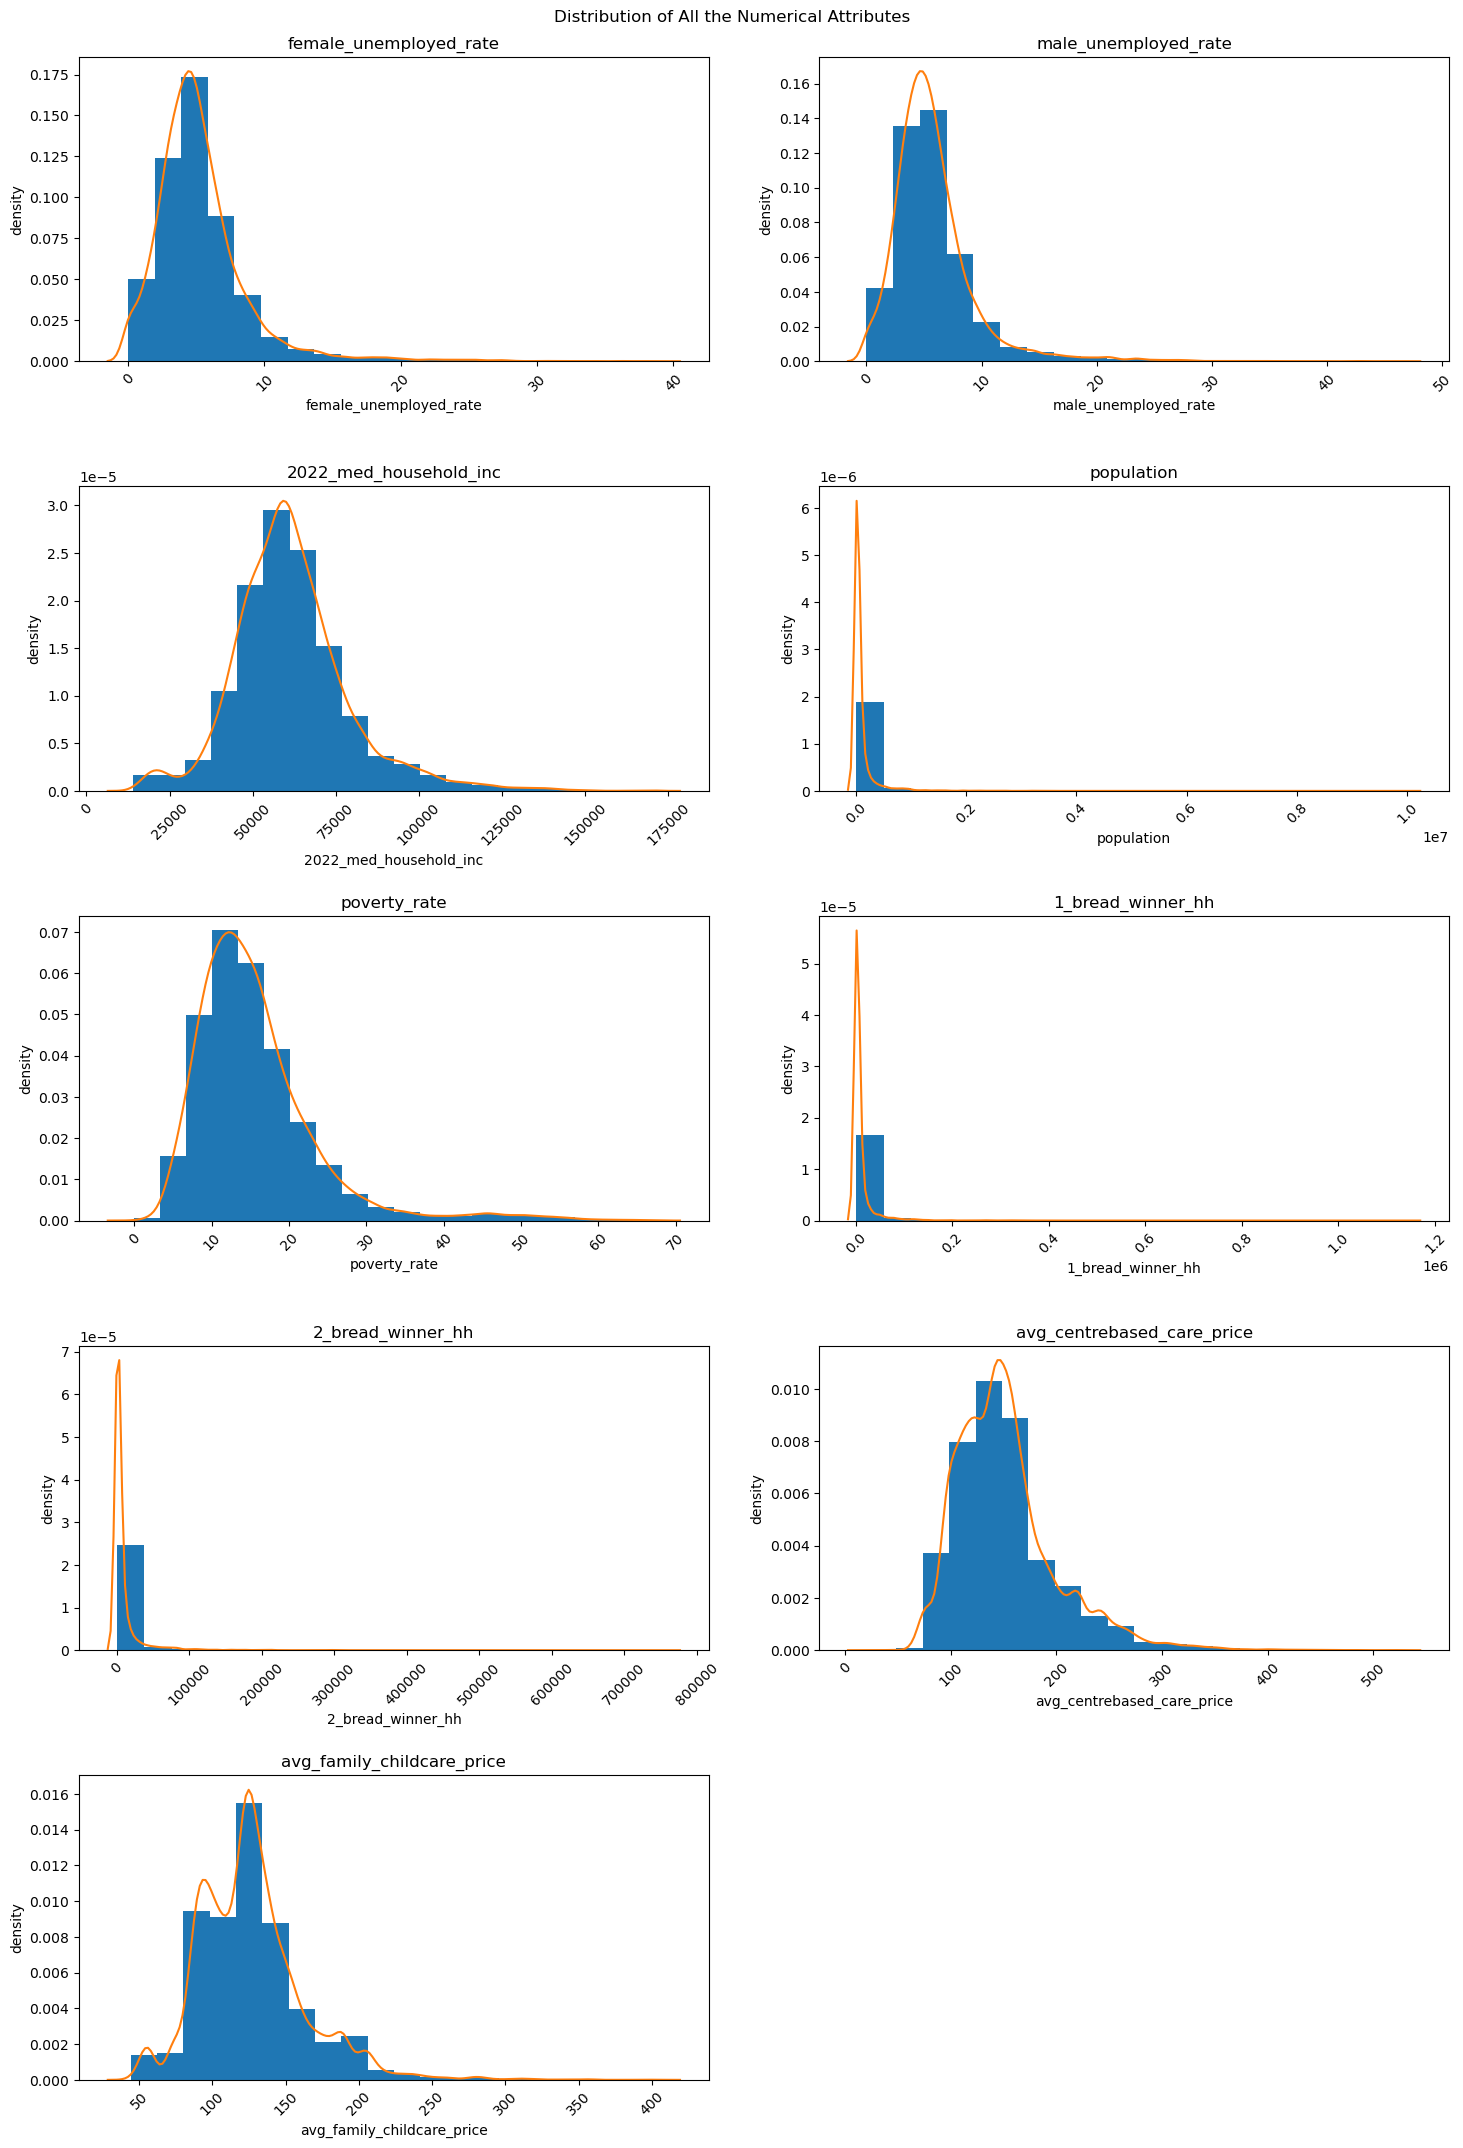

In [33]:
numeric_attr = ["female_unemployed_rate", "male_unemployed_rate", "2022_med_household_inc", "population", "poverty_rate", "1_bread_winner_hh", "2_bread_winner_hh", "avg_centrebased_care_price", "avg_family_childcare_price"]
curr_col = 1
cols = 2
rows = int(len(numeric_attr)/cols)
rows += 1 if rows * cols < len(numeric_attr) else rows #if the number of rows is not enough, add 1 to it (it means the list of plots needed is odd not even)

plt.figure(figsize=(15, 22))
for attribute in numeric_attr:
    plt.subplot(rows, cols, curr_col)
    plt.title(attribute)
    plt.hist(filtered_df[attribute], bins=20, density=True)#ploting with density instead of count
    sns.kdeplot(filtered_df[attribute])
    plt.xlabel(attribute)
    plt.xticks(rotation = 45)
    plt.ylabel("density")
    curr_col += 1
plt.suptitle("Distribution of All the Numerical Attributes")
plt.tight_layout(pad=2)
plt.show()

From the histogram and kernel density plots above, most of the attributes have a normal distribution but are mostly positively skewed with a few having some high outliers e.g. `unemployment_rate`, `poverty_rate`, and `population` have majority of their samples being on the lesser side, while having some extreemly high outlier state counties.

### 3.3) Analysing the relationship between the variables

Analysing the relationships between the numerical variables using correlation matrix

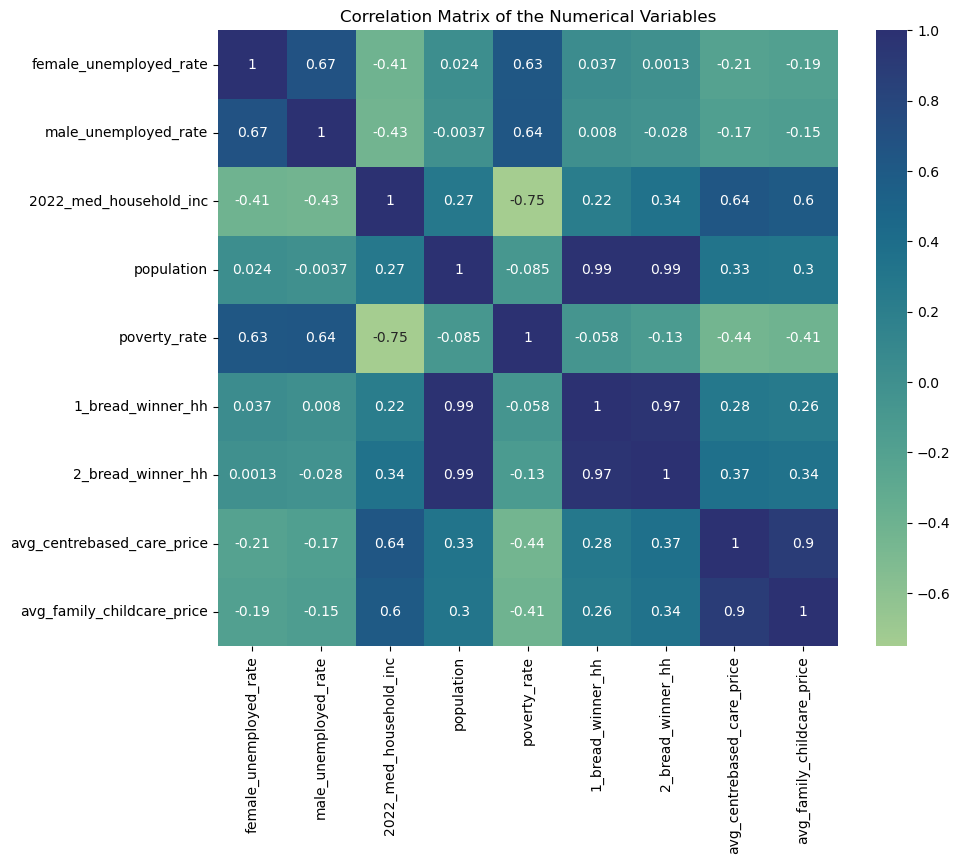

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(filtered_df[numeric_attr].corr(), cmap="crest", annot=True)
plt.title("Correlation Matrix of the Numerical Variables")
plt.show()

The correlation matrix shows that:
* Average centre-based care prices correlate with the price of family shildcare prices accross most of the state counties with 90% correlation.
* The child-care prices have around 60% correlation with the median houeshold income in each state county.
* The poverty rate in each state county is 63% correlated with the female unemployment rate and 64% correlated with the male unemployment rate.
* The population size has no correlation with the unemployment rates.

__Visulalising some of the variables that show correlation__

1) centre-based care prices against family child-care prices

In [35]:
#fc=(0.5, 0.7, 0.9)
def visualiseReationship(x, y, xlabel, ylabel, data_label = None, max_annot_text = "", marker = ".", transparent = False, size = 20):
    #scale the variables around their mean
    x_norm = (x - x.min()) / (x.max() - x.min()) #normalise the value of x
    y_norm = (y - y.min()) / (y.max() - y.min()) #normalise the value of y
    opacity = 1 if transparent == False else 0.5
    
    plt.scatter(x_norm, y_norm, marker=marker, label=data_label, alpha=opacity, s=size)
    if max_annot_text:
        plt.annotate(max_annot_text, xy = (x_norm.max()+0.03, y_norm.max()-0.01), bbox=dict(boxstyle="round", fc=(1.0, 0.7, 0.7), ec="none"))
    plt.xlabel(f"{xlabel} (scaled)")
    plt.ylabel(f"{ylabel} (scaled)")

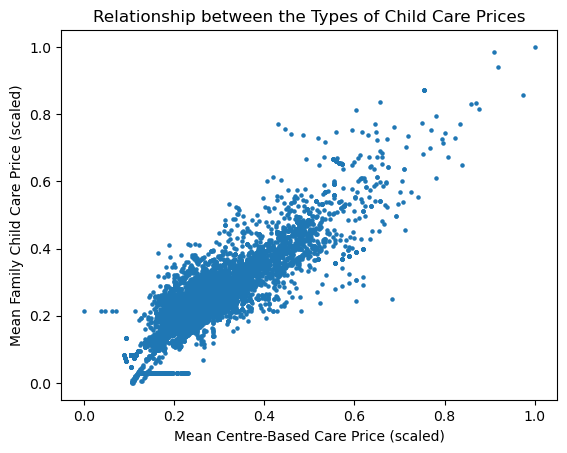

In [36]:
visualiseReationship(filtered_df["avg_centrebased_care_price"], filtered_df["avg_family_childcare_price"], xlabel="Mean Centre-Based Care Price", ylabel="Mean Family Child Care Price")
plt.title("Relationship between the Types of Child Care Prices")
plt.show()

2. Child Care Prices against Median Household Income

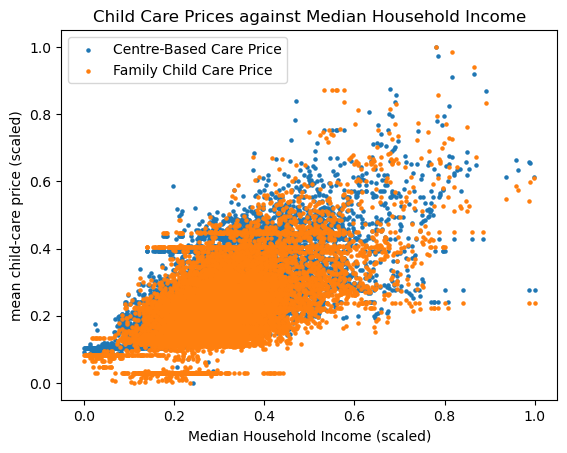

In [37]:
visualiseReationship(filtered_df["2022_med_household_inc"], filtered_df["avg_centrebased_care_price"], data_label="Centre-Based Care Price", xlabel="Median Household Income", ylabel="mean child-care price")
visualiseReationship(filtered_df["2022_med_household_inc"], filtered_df["avg_family_childcare_price"], data_label="Family Child Care Price", xlabel="Median Household Income", ylabel="mean child-care price")
plt.title("Child Care Prices against Median Household Income")
plt.legend()
plt.show()

Accross the three visualisations, the variables appear to have a linear relationship. However, on the visualisation showing the relationship between Median Household Income and Mean Child-Care Price, shows a more noisy relationship as it appears that some of the State Counties that have moderately high Median Household Income has low Mean Child-Care Price.

## 4.0) Analysing the Dataset Based on the Set Objectives

**Key Objectives of the Analysis**
* Analyse the US unemployment rate of males and females across 5 years (2018 to 2022).
* Analyse the relationship between unemployment rate the poverty rate levels per state by Gender.
* Analyse the median household income per State against the poverty rate per State in 2022.
* Analyse the effects of houseolds with only the father working compared to the both parents working on the poverty rate in the States in 2022.
* Analyse the median weekly family childcare and centre-based cares price against the poverty rate per US State in 2022.

### 4.1) Analysing the trend of average US unemployment and poverty rate across the years per gender

In [54]:
#show the data of the trends of poverty and unemployment rate trends
filtered_df[["studyyear", "poverty_rate", "male_unemployed_rate", "female_unemployed_rate"]].groupby("studyyear", as_index=False).mean()

,studyyear,poverty_rate,male_unemployed_rate,female_unemployed_rate
0,2018,16.393385,6.324130,5.788075
1,2019,15.893385,5.825093,5.288385
2,2020,15.380503,5.659578,5.212760
3,2021,15.174170,5.704626,5.199224
4,2022,15.099348,5.373176,4.903074


Visualising these variables to find patterns

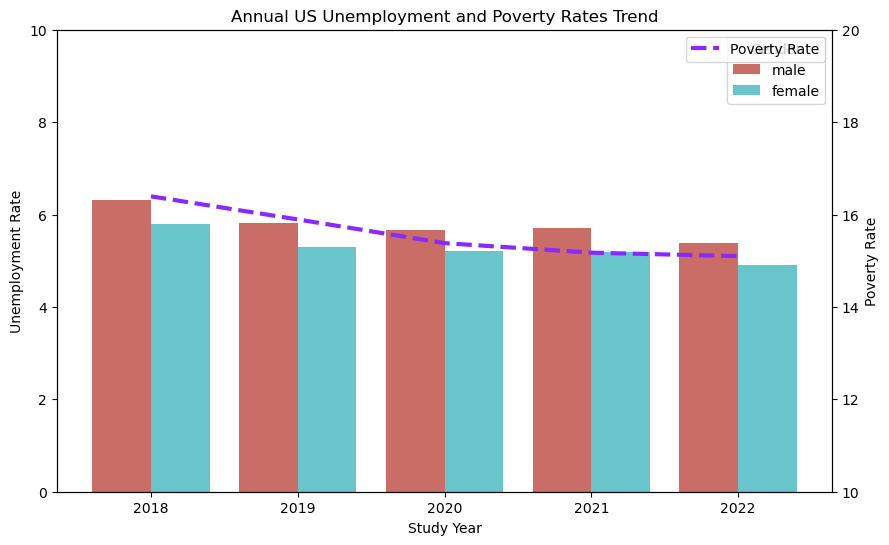

In [59]:
data = filtered_df[["studyyear", "male_unemployed_rate", "female_unemployed_rate"]].groupby("studyyear", as_index=False).mean()
data = data.rename({ #renaming this coulmn so the data label comes out shorter on the chart
    "male_unemployed_rate": "male",
    "female_unemployed_rate": "female"
}, axis=1)

#convert the table from wide table to long table such that there will be a new column containing the variable names of the melted columns and the second column being their corresponding values for each year
data = data.melt(id_vars="studyyear", var_name="Gender", value_name="Unemployment Rate") 
data = data.rename({"studyyear": "Study Year"}, axis = 1) #renaming this coulmn too so the x-label comes out readable on the chart

#Draw the grouped bar chart Visualisations to visualise the annual unemployment rate 
fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data = data, x = "Study Year", y = "Unemployment Rate", hue = "Gender", ax=ax1, palette= "hls") #use seaborn to plot the line chart
ax1.set_ylim(bottom = 0, top=10)

#Plot the poverty rate average over the years
ax2 = ax1.twinx()
poverty_rate_data = filtered_df[["studyyear", "poverty_rate"]].groupby("studyyear", as_index=False).mean()
ax2.plot(poverty_rate_data["poverty_rate"], c = "#8929ff", linestyle = "dashed", linewidth=3.0, label = "Poverty Rate")
ax2.set_ylabel("Poverty Rate")
ax2.set_ylim(bottom = 10, top = 20)
plt.legend()
plt.title("Annual US Unemployment and Poverty Rates Trend")
plt.show()

__Insights:__


### 4.2) Visualising the relationship between __Unemployment Rate__ the __Poverty Rate__ levels per State by Gender

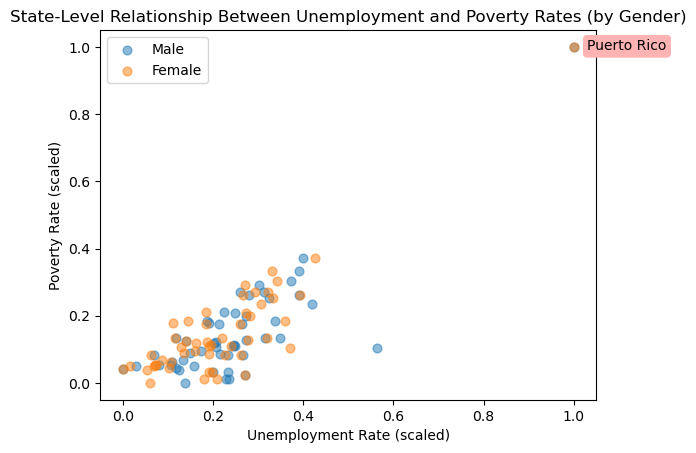

In [58]:
male_data = filtered_df[["state_name", "poverty_rate", "male_unemployed_rate"]].groupby(["state_name"]).mean()
female_data = filtered_df[["state_name", "poverty_rate", "female_unemployed_rate"]].groupby(["state_name"]).mean()
m_max_annotate_text = male_data[male_data["poverty_rate"] == male_data["poverty_rate"].max()].index[0] #to show the name of the state with the highest level of unemployment rate to poverty rate
f_max_annotate_text = female_data[female_data["poverty_rate"] == female_data["poverty_rate"].max()].index[0] #to show the name of the state with the highest level of unemployment rate to poverty rate

visualiseReationship(male_data["male_unemployed_rate"], male_data["poverty_rate"], data_label="Male", ylabel="Poverty Rate", xlabel="Unemployment Rate", max_annot_text = m_max_annotate_text,  marker="o", transparent=True, size = 40)
visualiseReationship(female_data["female_unemployed_rate"], female_data["poverty_rate"], data_label="Female", ylabel="Poverty Rate", xlabel="Unemployment Rate", max_annot_text = m_max_annotate_text, marker="o", transparent=True, size = 40)
plt.title("State-Level Relationship Between Unemployment and Poverty Rates (by Gender)")
plt.legend()
plt.show()

Showing the details of the State with the highest Unemployment Rate and Poverty Rate

In [41]:
poverty_rate = (male_data["poverty_rate"] + female_data["poverty_rate"])/2 #get the average poverty rate from the two genders
unemp_rate = (male_data["male_unemployed_rate"] + female_data["female_unemployed_rate"])/2 #get the average unemployment rate from the two genders
state_max_poverty_rate = poverty_rate.sort_values(ascending=False)[:1]
state_max_unemp_rate = unemp_rate.sort_values(ascending=False)[:1]
print(f"The State of '{state_max_unemp_rate.index[0]}' has Unemployment Rate of {round(state_max_unemp_rate.iloc[0], 2)}%")
print(f"The State of '{state_max_poverty_rate.index[0]}' has Poverty Rate of {round(state_max_poverty_rate.iloc[0], 2)}%")

The State of 'Puerto Rico' has Unemployment Rate of 15.81%
The State of 'Puerto Rico' has Poverty Rate of 46.68%


__Insights:__

### 4.3) Analysing the median household income per State against the poverty rate per State in 2022